This is for AI Session #41 video kmeans.py and Mall_Customers.csv
File location C:/Users/jaiam/OneDrive/2026/Training_2026/H2kInfosys-2026/AI_Data/Mall_Customers.csv

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA # PCA = Pxxx Consept Analysis

In [2]:
# -------------------------------
# 1. Load the dataset
# -------------------------------
df = pd.read_csv("C:/Users/jaiam/OneDrive/2026/Training_2026/H2kInfosys-2026/AI_Data/Mall_Customers.csv")

In [3]:
# Select features for clustering
X = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]

In [4]:
# -------------------------------
# 2. Scaling
# -------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [5]:
print(X_scaled)

[[-1.42456879 -1.73899919 -0.43480148]
 [-1.28103541 -1.73899919  1.19570407]
 [-1.3528021  -1.70082976 -1.71591298]
 [-1.13750203 -1.70082976  1.04041783]
 [-0.56336851 -1.66266033 -0.39597992]
 [-1.20926872 -1.66266033  1.00159627]
 [-0.27630176 -1.62449091 -1.71591298]
 [-1.13750203 -1.62449091  1.70038436]
 [ 1.80493225 -1.58632148 -1.83237767]
 [-0.6351352  -1.58632148  0.84631002]
 [ 2.02023231 -1.58632148 -1.4053405 ]
 [-0.27630176 -1.58632148  1.89449216]
 [ 1.37433211 -1.54815205 -1.36651894]
 [-1.06573534 -1.54815205  1.04041783]
 [-0.13276838 -1.54815205 -1.44416206]
 [-1.20926872 -1.54815205  1.11806095]
 [-0.27630176 -1.50998262 -0.59008772]
 [-1.3528021  -1.50998262  0.61338066]
 [ 0.94373197 -1.43364376 -0.82301709]
 [-0.27630176 -1.43364376  1.8556706 ]
 [-0.27630176 -1.39547433 -0.59008772]
 [-0.99396865 -1.39547433  0.88513158]
 [ 0.51313183 -1.3573049  -1.75473454]
 [-0.56336851 -1.3573049   0.88513158]
 [ 1.08726535 -1.24279661 -1.4053405 ]
 [-0.70690189 -1.24279661

In [6]:
# -------------------------------
# 3. Choose number of clusters (k)
# -------------------------------
k = 4   # You can change this (2,3,4,5...) depending on Elbow

In [7]:
kmeans = KMeans(n_clusters=k, random_state=42)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print(df['Cluster'])#it contains the values like 0,1,2,3

0      2
1      2
2      2
3      2
4      2
      ..
195    1
196    3
197    1
198    3
199    1
Name: Cluster, Length: 200, dtype: int32


In [8]:
# -------------------------------
# 4. Cluster Centers 
# -------------------------------
centers = scaler.inverse_transform(kmeans.cluster_centers_)
#simply it is going to convert my centroids back to orginal units
#otherwise u will get somethong age=0.8,income-1.1,score=-0.4
#these numbers are not directly meaningful to business point of view so simply applied
#inverse transform


centers_df = pd.DataFrame(centers, columns=X.columns)
print("\nCluster Centers:\n", centers_df)


Cluster Centers:
          Age  Annual Income (k$)  Spending Score (1-100)
0  53.984615           47.707692               39.969231
1  32.875000           86.100000               81.525000
2  25.438596           40.000000               60.298246
3  39.368421           86.500000               19.578947


In [9]:
# -------------------------------
# 5. PCA for 2D Visual Plot
# -------------------------------
#Reducing the features(dimenions) it will keep max important infomationn--it is easire for doing some plot

pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)
print("pca_data values", pca_data)

pca_data values [[-6.15720019e-01 -1.76348088e+00]
 [-1.66579271e+00 -1.82074695e+00]
 [ 3.37861909e-01 -1.67479894e+00]
 [-1.45657325e+00 -1.77242992e+00]
 [-3.84652078e-02 -1.66274012e+00]
 [-1.48168526e+00 -1.73500173e+00]
 [ 1.09461665e+00 -1.56610230e+00]
 [-1.92630736e+00 -1.72111049e+00]
 [ 2.64517786e+00 -1.46084721e+00]
 [-9.70130513e-01 -1.63558108e+00]
 [ 2.49568861e+00 -1.47048914e+00]
 [-1.45688256e+00 -1.66436050e+00]
 [ 2.01018729e+00 -1.45329897e+00]
 [-1.41321072e+00 -1.61776746e+00]
 [ 1.00042965e+00 -1.49579176e+00]
 [-1.56943170e+00 -1.62502669e+00]
 [ 2.94060318e-01 -1.49425585e+00]
 [-1.31624924e+00 -1.57216383e+00]
 [ 1.31669910e+00 -1.37243404e+00]
 [-1.43679899e+00 -1.51039469e+00]
 [ 2.88561175e-01 -1.37988135e+00]
 [-1.26018513e+00 -1.45723906e+00]
 [ 1.66684303e+00 -1.27396755e+00]
 [-9.57849842e-01 -1.40613544e+00]
 [ 1.82015978e+00 -1.15548636e+00]
 [-1.31148032e+00 -1.30928557e+00]
 [ 8.70423506e-01 -1.20135126e+00]
 [-4.31580912e-01 -1.26551061e+00]
 [ 6

In [10]:
#Here PC1 and PC2 includes all information from orginal features

#These PC1 and PC2 are the new features created by PCA it helped us to reduce dimension while keeping most of the in
#formationmin the data..


#print("PCA_DATA",pca_data)
df['PC1'] = pca_data[:,0]#Most imp new feature
df['PC2'] = pca_data[:,1]#second most imp new feature

#They are not orginal features like Age,income...
#they are created features that combine original features in a smart way
#pc1=age+income+spending_score
#pc2=age+income+spending_score

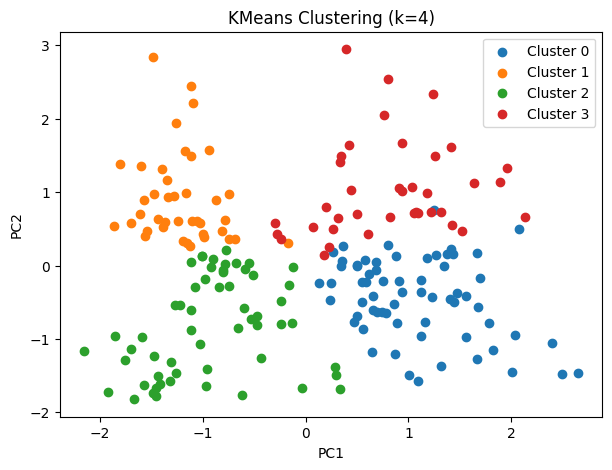

In [11]:
plt.figure(figsize=(7,5))
for cluster in range(k):#k=4-->0,1,2,3
    d = df[df['Cluster'] == cluster]
    plt.scatter(d['PC1'], d['PC2'], label=f"Cluster {cluster}")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title(f"KMeans Clustering (k={k})")
plt.legend()
plt.show()

In [12]:
# -------------------------------
# 6. See first few rows
# -------------------------------
print("\nSample with cluster labels:\n")
print(df.head())


Sample with cluster labels:

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   

   Cluster       PC1       PC2  
0        2 -0.615720 -1.763481  
1        2 -1.665793 -1.820747  
2        2  0.337862 -1.674799  
3        2 -1.456573 -1.772430  
4        2 -0.038465 -1.662740  


This is end of AI Session #41 video